In [10]:
from pkg_resources import resource_stream
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import skimage.color
from skimage.segmentation import mark_boundaries
from timeit import default_timer as timer
from itertools import chain
from pysnic.algorithms.snic import snic, compute_grid
from pysnic.ndim.operations_collections import nd_computations
from pysnic.metric.snic import create_augmented_snic_distance

from osgeo import gdal
import rasterio

In [11]:
# imgPath = "/data/gis/gis_projects/2022/22-331_NASA_ABoVE_WesternAK_Synthesis_mason/shrub_modeling/20230309_JJsquare1/mini1000pix.tif"
# segPath = "/data/gis/gis_projects/2022/22-331_NASA_ABoVE_WesternAK_Synthesis_mason/shrub_modeling/20230309_JJsquare1/mini1000pix_segs.tif"

imgPath = "/data/gis/gis_projects/2022/22-331_NASA_ABoVE_WesternAK_Synthesis_mason/shrub_modeling/20230309_JJsquare1/WV02_20120721_M1BS_103001001AB23900-sr-02m_jj001.tif"
# segPath = "/data/gis/gis_projects/2022/22-331_NASA_ABoVE_WesternAK_Synthesis_mason/shrub_modeling/20230309_JJsquare1/WV02_20120721_M1BS_103001001AB23900-sr-02m_jj001_segs_400sqm_c10.tif"
segPath = "/data/gis/gis_projects/2022/22-331_NASA_ABoVE_WesternAK_Synthesis_mason/shrub_modeling/20230309_JJsquare1/WV02_20120721_M1BS_103001001AB23900-sr-02m_jj001_segs_100sqm_c10.tif"


In [12]:
def read_geotiff(filename):
    ds = gdal.Open(filename)
    # band = ds.GetRasterBand(1)
    arr = ds.ReadAsArray()
    arr = np.transpose(arr, [1, 2, 0])
    return arr, ds

def write_geotiff(filename, arr, in_ds):
    if arr.dtype == np.float32:
        arr_type = gdal.GDT_Float32
    else:
        arr_type = gdal.GDT_Int32

    driver = gdal.GetDriverByName("GTiff")
    out_ds = driver.Create(filename, arr.shape[1], arr.shape[0], 1, arr_type)
    out_ds.SetProjection(in_ds.GetProjection())
    out_ds.SetGeoTransform(in_ds.GetGeoTransform())
    band = out_ds.GetRasterBand(1)
    band.WriteArray(arr)
    band.FlushCache()
    band.ComputeStatistics(False)



In [13]:
# with rasterio.open(imgPath, 'r') as ds:
#     image = ds.read()  # read all raster values
#     image = np.transpose(image, [1, 2, 0])

arr, image = read_geotiff(imgPath)

print(arr.shape[0],arr.shape[1],arr.shape[2])
number_of_pixels = arr.shape[0] * arr.shape[1]
number_of_pixels

5000 5000 4


25000000

In [14]:
area_sqm = number_of_pixels * 4
target_polygon_size_sqm = 100 #400
target_numSegments = round(area_sqm / target_polygon_size_sqm)
area_sqm, target_polygon_size_sqm, target_numSegments

(100000000, 100, 1000000)

In [15]:
# SNIC parameters
numSegments = target_numSegments
compactness = 10.0

# compute grid
grid = compute_grid(arr.shape, numSegments)
seeds = list(chain.from_iterable(grid))
seed_len = len(seeds)

# choose a distance metric
distance_metric = create_augmented_snic_distance(arr.shape, seed_len, compactness)


start = timer()

segmentation, distances, centroids = snic(
    arr,
    # skimage.color.rgb2lab(color_image).tolist(),
    seeds,
    compactness, nd_computations["3"], distance_metric,
    update_func=lambda num_pixels: print("processed %05.2f%%" % (num_pixels * 100 / number_of_pixels)))

end = timer()
print("superpixelation took: %fs" % (end - start))



processed 00.04%
processed 00.08%
processed 00.12%
processed 00.16%
processed 00.20%
processed 00.24%
processed 00.28%
processed 00.32%
processed 00.36%
processed 00.40%
processed 00.44%
processed 00.48%
processed 00.52%
processed 00.56%
processed 00.60%
processed 00.64%
processed 00.68%
processed 00.72%
processed 00.76%
processed 00.80%
processed 00.84%
processed 00.88%
processed 00.92%
processed 00.96%
processed 01.00%
processed 01.04%
processed 01.08%
processed 01.12%
processed 01.16%
processed 01.20%
processed 01.24%
processed 01.28%
processed 01.32%
processed 01.36%
processed 01.40%
processed 01.44%
processed 01.48%
processed 01.52%
processed 01.56%
processed 01.60%
processed 01.64%
processed 01.68%
processed 01.72%
processed 01.76%
processed 01.80%
processed 01.84%
processed 01.88%
processed 01.92%
processed 01.96%
processed 02.00%
processed 02.04%
processed 02.08%
processed 02.12%
processed 02.16%
processed 02.20%
processed 02.24%
processed 02.28%
processed 02.32%
processed 02.3

In [16]:
# show the output of SNIC
# plt.figure("SNIC with %d segments" % len(centroids))
# plt.imshow(mark_boundaries(image, np.array(segmentation)))
# plt.show()

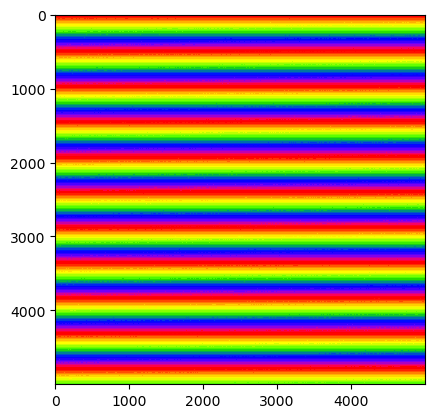

In [17]:
plt.figure("segmentations")
plt.imshow(segmentation, cmap="prism")
plt.show()

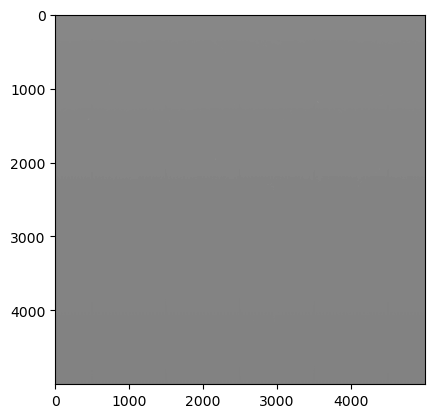

In [18]:
# show the distance map
plt.figure("Distances")
plt.imshow(distances, cmap="gray")
plt.show()

In [19]:
len(centroids)

1002001

In [20]:
np.array(segmentation).shape

(5000, 5000)

In [21]:
write_geotiff(segPath, np.array(segmentation), image)

# from osgeo import gdal
# import numpy as np
# import matplotlib.pyplot as plt

